In [3]:
import pandas as pd


In [4]:
tabel = pd.read_csv("parallelisation.csv")
tabel.head()

,ED,intextSwitchpoint,GPU_time,CPU_time,Threads,GPU_matches,CPU_matches
0,3,1,2:38.02,2:18.73,1,23632628,23632628
1,3,1,2:37.62,2:19.37,1,23632628,23632628
2,3,1,3:03.46,2:19.68,1,23632628,23632628
3,3,1,2:37.53,2:19.56,1,23632628,23632628
4,3,1,2:37.82,2:20.35,1,23632628,23632628


In [5]:
def mmss_to_seconds(t):
    minuten, rest = t.split(":")
    seconden = float(rest)
    return int(minuten) * 60 + seconden


In [6]:
tabel["gpu_tijd"] = pd.to_timedelta(
    tabel["GPU_time"].apply(mmss_to_seconds),
    unit="s"
)

tabel["cpu_tijd"] = pd.to_timedelta(
    tabel["CPU_time"].apply(mmss_to_seconds),
    unit="s"
)
tabel

,ED,intextSwitchpoint,GPU_time,CPU_time,Threads,GPU_matches,CPU_matches,gpu_tijd,cpu_tijd
0,3,1,2:38.02,2:18.73,1,23632628,23632628,0 days 00:02:38.020000,0 days 00:02:18.730000
1,3,1,2:37.62,2:19.37,1,23632628,23632628,0 days 00:02:37.620000,0 days 00:02:19.370000
2,3,1,3:03.46,2:19.68,1,23632628,23632628,0 days 00:03:03.460000,0 days 00:02:19.680000
3,3,1,2:37.53,2:19.56,1,23632628,23632628,0 days 00:02:37.530000,0 days 00:02:19.560000
4,3,1,2:37.82,2:20.35,1,23632628,23632628,0 days 00:02:37.820000,0 days 00:02:20.350000
...,...,...,...,...,...,...,...,...,...
145,5,5,1:31.42,1:43.28,10,68767458,68767458,0 days 00:01:31.420000,0 days 00:01:43.280000
146,5,5,1:31.27,1:42.57,10,68767458,68767458,0 days 00:01:31.270000,0 days 00:01:42.570000
147,5,5,1:30.72,2:09.10,10,68767458,68767458,0 days 00:01:30.720000,0 days 00:02:09.100000
148,5,5,1:30.12,1:42.70,10,68767458,68767458,0 days 00:01:30.120000,0 days 00:01:42.700000


In [7]:
stats = (
    tabel
    .groupby(["ED", "intextSwitchpoint", "Threads"])
    .agg(
        gpu_mean=("gpu_tijd", "mean"),
        gpu_sem=("gpu_tijd", "std"),
        cpu_mean=("cpu_tijd", "mean"),
        cpu_sem=("cpu_tijd", "std"),
        n=("gpu_tijd", "size")

    )
    .reset_index()
)

stats["gpu_sem"] = stats["gpu_sem"] / stats["n"] ** 0.5
stats["cpu_sem"] = stats["cpu_sem"] / stats["n"] ** 0.5


In [8]:
stats

,ED,intextSwitchpoint,Threads,gpu_mean,gpu_sem,cpu_mean,cpu_sem,n
0,3,1,1,0 days 00:02:42.890000,0 days 00:00:05.143195504,0 days 00:02:19.538000,0 days 00:00:00.260871615,5
1,3,1,2,0 days 00:01:16.372000,0 days 00:00:00.119891617,0 days 00:01:11.924000,0 days 00:00:00.056267219,5
2,3,1,4,0 days 00:00:39.416000,0 days 00:00:00.072013887,0 days 00:00:37.478000,0 days 00:00:00.052573757,5
3,3,1,8,0 days 00:00:21.732000,0 days 00:00:00.040669398,0 days 00:00:20.624000,0 days 00:00:00.359480179,5
4,3,1,10,0 days 00:00:18.414000,0 days 00:00:00.035156791,0 days 00:00:17.426000,0 days 00:00:00.591046529,5
5,3,3,1,0 days 00:02:33.724000,0 days 00:00:00.237014767,0 days 00:02:22.916000,0 days 00:00:00.196458646,5
6,3,3,2,0 days 00:01:14.100000,0 days 00:00:00.134796142,0 days 00:01:12.496000,0 days 00:00:00.074605629,5
7,3,3,4,0 days 00:00:38.352000,0 days 00:00:00.064218377,0 days 00:00:37.860000,0 days 00:00:00.044158804,5
8,3,3,8,0 days 00:00:21.250000,0 days 00:00:00.013038404,0 days 00:00:20.442000,0 days 00:00:00.024372115,5
9,3,3,10,0 days 00:00:18.030000,0 days 00:00:00.039999999,0 days 00:00:17.004000,0 days 00:00:00.007483314,5


In [9]:
plot_df = stats.copy()

plot_df["gpu_mean"] = plot_df["gpu_mean"].dt.total_seconds()
plot_df["gpu_sem"]  = plot_df["gpu_sem"].dt.total_seconds()
plot_df["cpu_mean"] = plot_df["cpu_mean"].dt.total_seconds()
plot_df["cpu_sem"]  = plot_df["cpu_sem"].dt.total_seconds()


In [10]:
# baseline per (ED, intextSwitchpoint)
baseline = (
    plot_df[plot_df["Threads"] == 1]
    [["ED", "intextSwitchpoint", "cpu_mean", "cpu_sem"]]
    .rename(columns={
        "cpu_mean": "cpu_mean_ref",
        "cpu_sem": "cpu_sem_ref"
    })
)

# merge terug op originele dataframe
plot_df = plot_df.merge(
    baseline,
    on=["ED", "intextSwitchpoint"],
    how="left"
)

# speedup berekenen
plot_df["speedup_cpu"] = plot_df["cpu_mean_ref"] / plot_df["cpu_mean"]
plot_df["speedup_cpu_sem"] = plot_df["speedup_cpu"] * (
    (plot_df["cpu_sem_ref"] / plot_df["cpu_mean_ref"])**2 +
    (plot_df["cpu_sem"] / plot_df["cpu_mean"])**2
) ** 0.5

baseline = (
    plot_df[plot_df["Threads"] == 1]
    [["ED", "intextSwitchpoint", "gpu_mean", "gpu_sem"]]
    .rename(columns={
        "gpu_mean": "gpu_mean_ref",
        "gpu_sem": "gpu_sem_ref"
    })
)

# merge terug op originele dataframe
plot_df = plot_df.merge(
    baseline,
    on=["ED", "intextSwitchpoint"],
    how="left"
)

# speedup berekenen
plot_df["speedup_gpu"] = plot_df["gpu_mean_ref"] / plot_df["gpu_mean"]
plot_df["speedup_gpu_sem"] = plot_df["speedup_gpu"] * (
    (plot_df["gpu_sem_ref"] / plot_df["gpu_mean_ref"])**2 +
    (plot_df["gpu_sem"] / plot_df["gpu_mean"])**2
) ** 0.5
plot_df = plot_df.drop(columns=["gpu_mean_ref", "gpu_sem_ref", "cpu_mean_ref", "cpu_sem_ref"])
plot_df.loc[plot_df["Threads"] == 1, "speedup_gpu_sem"] = 0
plot_df.loc[plot_df["Threads"] == 1, "speedup_cpu_sem"] = 0

In [11]:
plot_df

,ED,intextSwitchpoint,Threads,gpu_mean,gpu_sem,cpu_mean,cpu_sem,n,speedup_cpu,speedup_cpu_sem,speedup_gpu,speedup_gpu_sem
0,3,1,1,162.890,5.143196,139.538,0.260872,5,1.000000,0.000000,1.000000,0.000000
1,3,1,2,76.372,0.119892,71.924,0.056267,5,1.940076,0.003932,2.132850,0.067427
2,3,1,4,39.416,0.072014,37.478,0.052574,5,3.723198,0.008702,4.132586,0.130703
3,3,1,8,21.732,0.040669,20.624,0.359480,5,6.765807,0.118606,7.495398,0.237080
4,3,1,10,18.414,0.035157,17.426,0.591047,5,8.007460,0.272005,8.845987,0.279819
5,3,3,1,153.724,0.237015,142.916,0.196459,5,1.000000,0.000000,1.000000,0.000000
6,3,3,2,74.100,0.134796,72.496,0.074606,5,1.971364,0.003385,2.074548,0.004947
7,3,3,4,38.352,0.064218,37.860,0.044159,5,3.774855,0.006805,4.008239,0.009123
8,3,3,8,21.250,0.013038,20.442,0.024372,5,6.991292,0.012722,7.234071,0.012004
9,3,3,10,18.030,0.040000,17.004,0.007483,5,8.404846,0.012131,8.526012,0.023035


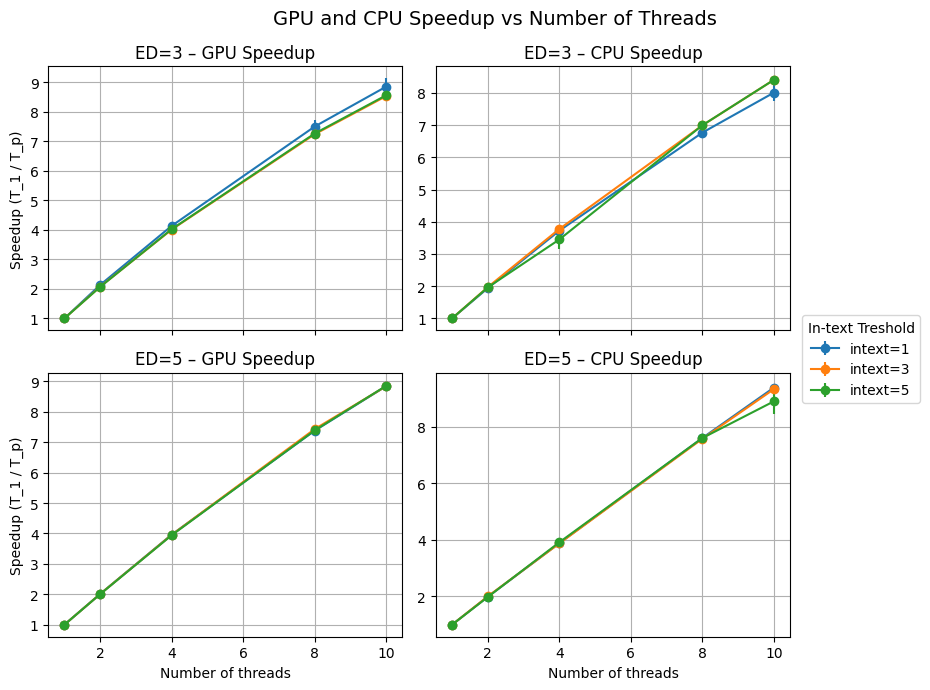

In [12]:
import matplotlib.pyplot as plt

eds = sorted(plot_df["ED"].unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

for i, ed in enumerate(eds):
    ed_df = plot_df[plot_df["ED"] == ed]

    # ---------- GPU SPEEDUP ----------
    ax = axes[i, 0]
    for intext, subset in ed_df.groupby("intextSwitchpoint"):
        subset = subset.sort_values("Threads")

        ax.errorbar(
            subset["Threads"],
            subset["speedup_gpu"],
            yerr=subset["speedup_gpu_sem"],
            marker="o",
            label=f"intext={intext}"
        )

    ax.set_title(f"ED={ed} – GPU Speedup")
    ax.set_ylabel("Speedup (T_1 / T_p)")
    ax.grid(True)

    # ---------- CPU SPEEDUP ----------
    ax = axes[i, 1]
    for intext, subset in ed_df.groupby("intextSwitchpoint"):
        subset = subset.sort_values("Threads")

        ax.errorbar(
            subset["Threads"],
            subset["speedup_cpu"],
            yerr=subset["speedup_cpu_sem"],
            marker="o",
            label=f"intext={intext}"
        )

    ax.set_title(f"ED={ed} – CPU Speedup")
    ax.grid(True)

# x-as labels alleen onder
axes[1, 0].set_xlabel("Number of threads")
axes[1, 1].set_xlabel("Number of threads")

# gezamenlijke legenda
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="In-text Treshold",
    loc="center left",
    bbox_to_anchor=(0.8, 0.48)
)

fig.suptitle("GPU and CPU Speedup vs Number of Threads", fontsize=14)
plt.subplots_adjust(right=0.8, top=0.85)
plt.tight_layout(rect=[0, 0, 0.81, 1])
plt.show()
fig.savefig("parallel_speed.pdf")


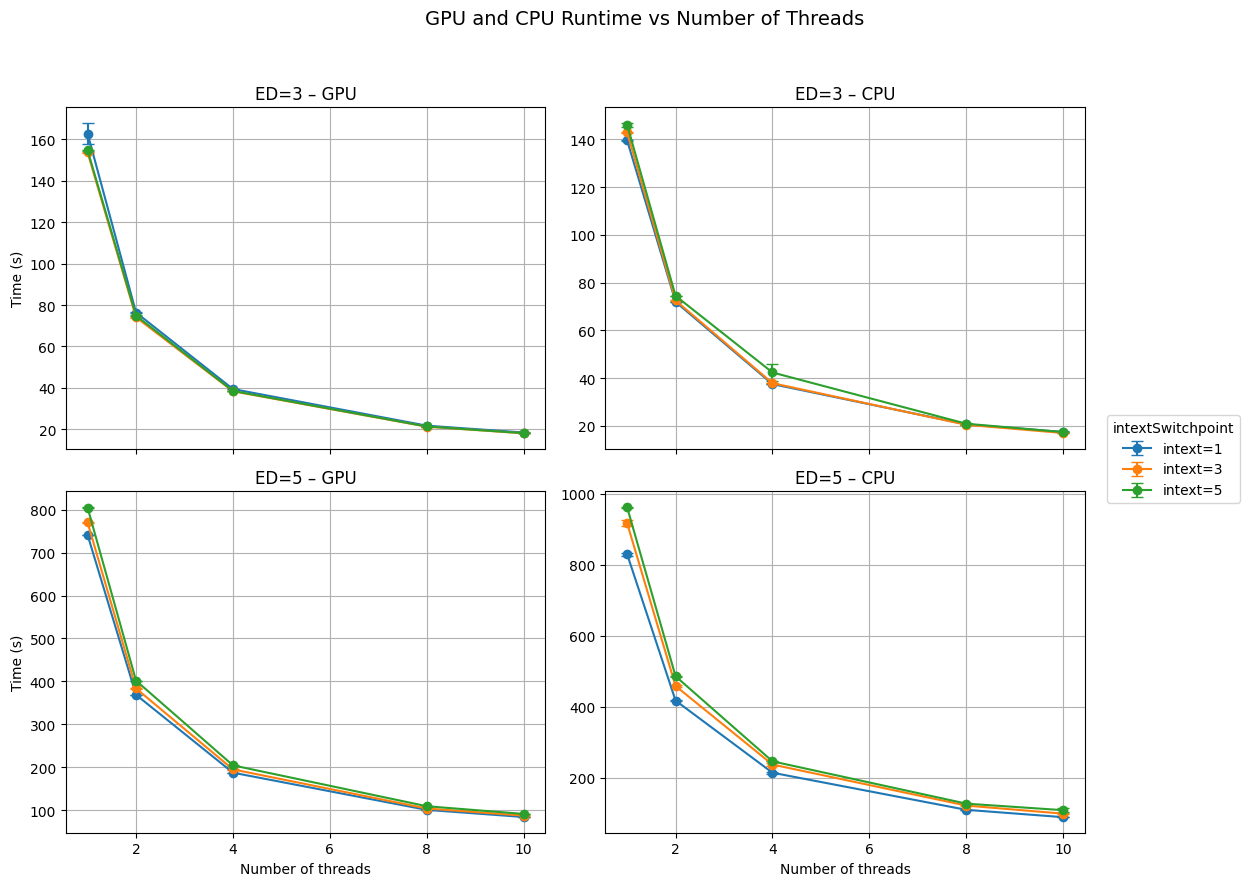

In [13]:
import matplotlib.pyplot as plt

eds = sorted(plot_df["ED"].unique())

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for i, ed in enumerate(eds):
    ed_df = plot_df[plot_df["ED"] == ed]

    # ---------- GPU ----------
    ax = axes[i, 0]
    for intext, subset in ed_df.groupby("intextSwitchpoint"):
        subset = subset.sort_values("Threads")
        ax.errorbar(
            subset["Threads"],
            subset["gpu_mean"],
            yerr=subset["gpu_sem"],
            marker="o",
            capsize=4,
            label=f"intext={intext}"
        )
    ax.set_title(f"ED={ed} – GPU")
    ax.set_ylabel("Time (s)")
    ax.grid(True)

    # ---------- CPU ----------
    ax = axes[i, 1]
    for intext, subset in ed_df.groupby("intextSwitchpoint"):
        subset = subset.sort_values("Threads")
        ax.errorbar(
            subset["Threads"],
            subset["cpu_mean"],
            yerr=subset["cpu_sem"],
            marker="o",
            capsize=4,
            label=f"intext={intext}"
        )
    ax.set_title(f"ED={ed} – CPU")
    ax.grid(True)

# x-as labels alleen onder
axes[1, 0].set_xlabel("Number of threads")
axes[1, 1].set_xlabel("Number of threads")

# Eén gezamenlijke legenda
# ... (alle plotcode blijft hetzelfde)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="intextSwitchpoint",
    loc="center left",
    bbox_to_anchor=(0.85, 0.48)
)

fig.suptitle("GPU and CPU Runtime vs Number of Threads", fontsize=14)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


fig.savefig("parallel.pdf")


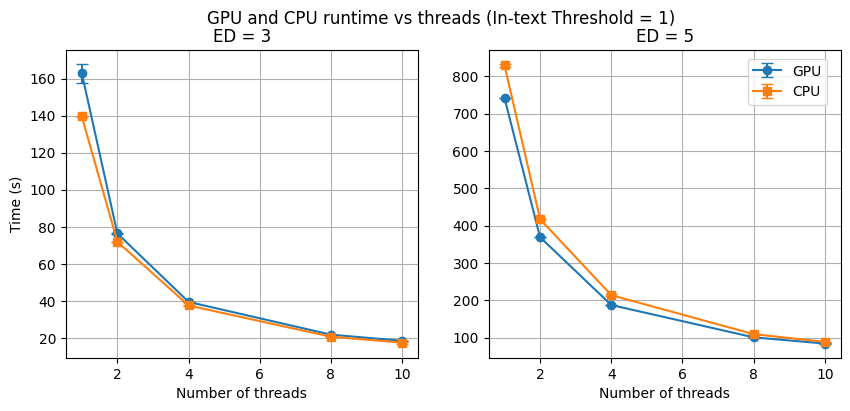

In [14]:
import matplotlib.pyplot as plt

# Filter alleen intextSwitchpoint == 1
df = plot_df[plot_df["intextSwitchpoint"] == 1]

eds = [3, 5]
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=False)

for ax, ed in zip(axes, eds):
    ed_df = df[df["ED"] == ed].sort_values("Threads")

    # GPU
    ax.errorbar(
        ed_df["Threads"],
        ed_df["gpu_mean"],
        yerr=ed_df["gpu_sem"],
        marker="o",
        capsize=4,
        color="tab:blue",
        label="GPU",
    )

    # CPU
    ax.errorbar(
        ed_df["Threads"],
        ed_df["cpu_mean"],
        yerr=ed_df["cpu_sem"],
        marker="s",
        capsize=4,
        color="tab:orange",
        label="CPU",
    )

    ax.set_title(f"ED = {ed}")
    ax.set_xlabel("Number of threads")
    ax.grid(True, axis="both")

axes[0].set_ylabel("Time (s)")

# gezamenlijke legenda
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.8, 0.8)
)

fig.suptitle("GPU and CPU runtime vs threads (In-text Threshold = 1)")
fig.savefig("parallel_runtimes.pdf")
plt.show()



In [ ]:
df2 = pd.read_csv("results_Threshold.csv")
df2.head()

,ed,depth,size,time
0,3,1,598005,NaN
1,3,1,674769,NaN
2,3,1,647745,NaN
3,3,1,650592,NaN
4,3,1,635442,NaN


In [16]:
sum = df2.groupby(["ed", "depth"], as_index=False).sum()
sum


,ed,depth,size,time
0,3,1,26237858,0.0
1,3,2,35149711,0.0
2,3,3,45151159,0.0
3,3,4,51032392,0.0
4,3,5,55110495,0.0
5,3,6,59752464,0.0
6,3,7,62930206,0.0
7,3,8,66054415,0.0
8,3,9,69275507,0.0
9,3,10,71710504,0.0


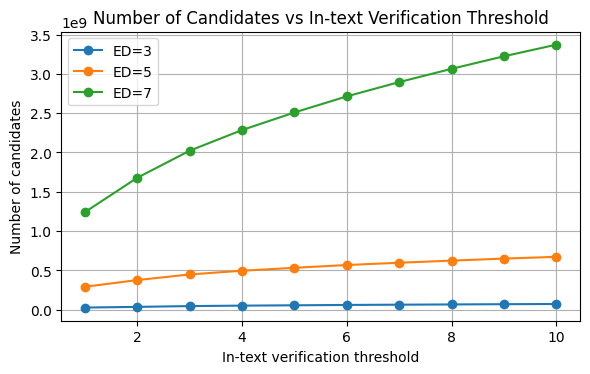

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

for ed_value in sum["ed"].unique():
    subset = sum[sum["ed"] == ed_value]
    ax.plot(subset["depth"], subset["size"], marker="o", label=f"ED={ed_value}")

ax.set_xlabel("In-text verification threshold")
ax.set_ylabel("Number of candidates")
ax.set_title("Number of Candidates vs In-text Verification Threshold")
ax.legend()
ax.grid(True)

fig.tight_layout()
fig.savefig("intext.pdf")
plt.show()


In [18]:
df3 = pd.read_csv("results_ED.csv")
df3.head()

,ed,depth,size,time_ms
0,1,1,51151,NaN
1,1,1,53135,NaN
2,1,1,53407,NaN
3,1,1,50269,NaN
4,1,1,50669,NaN


In [19]:
df3 = df3.groupby(["ed"]).sum()
df3.head()
df3 = df3.reset_index()
df3

,ed,depth,size,time_ms
0,1,40,2120641,0.0
1,2,40,7392751,0.0
2,3,40,26237858,0.0
3,4,40,92038668,0.0
4,5,40,290811519,0.0
5,6,40,529137793,0.0
6,7,40,1240046151,0.0
7,8,40,8949715236,0.0
8,9,40,25531004480,0.0


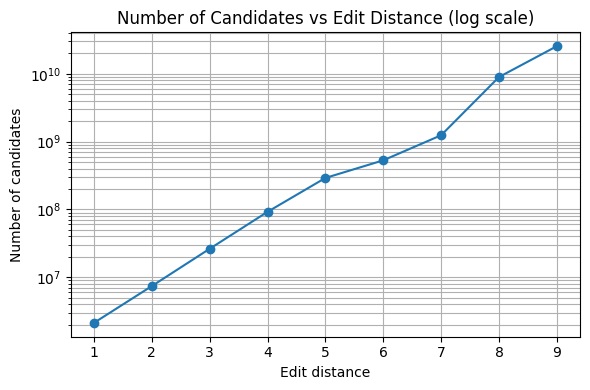

In [20]:
import matplotlib.pyplot as plt

# df bevat alle 9 punten
# zorg dat size > 0 (log kan niet overweg met nul/negatief)

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(df3["ed"], df3["size"], marker="o")
ax.set_xlabel("Edit distance")
ax.set_ylabel("Number of candidates")
ax.set_title("Number of Candidates vs Edit Distance (log scale)")

ax.set_yscale("log")   # y-as log
ax.grid(True, which="both")  # ook kleine gridlines

plt.tight_layout()
plt.show()
fig.savefig("ed.pdf")



In [21]:
df = pd.read_csv("final.csv")
df["GPU_time"] = pd.to_timedelta(
    df["GPU_time"].apply(mmss_to_seconds),
    unit="s"
).dt.total_seconds()

df["CPU_time"] = pd.to_timedelta(
    df["CPU_time"].apply(mmss_to_seconds),
    unit="s"
).dt.total_seconds()

df

,ED,intextSwitchpoint,GPU_time,CPU_time,Threads,GPU_matches,CPU_matches
0,1,0,9.97,8.12,10,6385689,6385689
1,1,0,9.99,8.11,10,6385689,6385689
2,1,0,9.93,14.79,10,6385689,6385689
3,1,0,9.94,8.13,10,6385689,6385689
4,1,0,9.92,8.14,10,6385689,6385689
...,...,...,...,...,...,...,...
413,8,5,2243.93,2883.42,10,254990229,254990379
414,8,7,2281.77,2965.80,10,254990232,254990382
415,8,8,2320.75,3055.79,10,254990239,254990395
416,8,9,2339.21,3250.32,10,254990266,254990423


In [22]:

df["GPU_matches"] = pd.to_numeric(df["GPU_matches"], errors="coerce")
df = df.groupby(["ED", " intextSwitchpoint"]).agg(GPU_time=("GPU_time", "mean"),
                                                  GPU_err = ("GPU_time", "std"),
                                                  CPU_time=("CPU_time", "mean"),
                                                  CPU_err = ("CPU_time", "std"),
                                                  GPU_matches=("GPU_matches", "mean"),
                                                  CPU_matches=("CPU_matches", "mean"),
                                                  n=("GPU_time", "size")
                                                  )
df = df.reset_index()
mask = df[" intextSwitchpoint"] == 0
df.loc[mask, "GPU_time"] = df.loc[mask, "CPU_time"]
df.loc[mask, "GPU_err"] = df.loc[mask, "CPU_err"]
df["GPU_err"] = df["GPU_err"] / df["n"] ** 0.5
df["CPU_err"] = df["CPU_err"] / df["n"] ** 0.5
df


,ED,intextSwitchpoint,GPU_time,GPU_err,CPU_time,CPU_err,GPU_matches,CPU_matches,n
0,1,0,9.458000,1.333009,9.458000,1.333009,6385689.0,6385689.0,5
1,1,1,8.288000,0.021307,6.408000,0.005831,6385689.0,6385689.0,5
2,1,2,8.208000,0.018547,6.380000,0.007071,6385689.0,6385689.0,5
3,1,3,8.164000,0.009274,6.356000,0.006782,6385689.0,6385689.0,5
4,1,4,8.138000,0.009695,6.352000,0.004899,6385689.0,6385689.0,5
...,...,...,...,...,...,...,...,...,...
83,8,6,2238.160000,NaN,2845.310000,NaN,254990237.0,254990385.0,1
84,8,7,2264.416667,12.830050,2923.906667,23.840910,254990232.0,254990382.0,3
85,8,8,2311.640000,10.085242,3001.753333,33.219204,254990239.0,254990395.0,3
86,8,9,2321.190000,12.077323,3138.463333,55.946145,254990266.0,254990423.0,3


In [23]:
df_cpu = df.copy()
df_cpu = df_cpu.drop(columns=["GPU_time", "GPU_err", "n", "GPU_matches"])
ref = df_cpu[df_cpu[" intextSwitchpoint"] == 0].set_index("ED")["CPU_time"]
ref_err = df_cpu[df_cpu[" intextSwitchpoint"] == 0].set_index("ED")["CPU_err"]
df_cpu["speedup"] = df_cpu["ED"].map(ref)/df_cpu["CPU_time"]
df_cpu["speedup_err"] = df_cpu["speedup"]*((df_cpu["ED"].map(ref_err)/df_cpu["ED"].map(ref))**2+(df_cpu["CPU_err"]/df_cpu["CPU_time"])**2)**(0.5)
df_cpu


,ED,intextSwitchpoint,CPU_time,CPU_err,CPU_matches,speedup,speedup_err
0,1,0,9.458000,1.333009,6385689.0,1.000000,0.199319
1,1,1,6.408000,0.005831,6385689.0,1.475968,0.208027
2,1,2,6.380000,0.007071,6385689.0,1.482445,0.208942
3,1,3,6.356000,0.006782,6385689.0,1.488043,0.209731
4,1,4,6.352000,0.004899,6385689.0,1.488980,0.209860
...,...,...,...,...,...,...,...
83,8,6,2845.310000,NaN,254990385.0,0.551053,NaN
84,8,7,2923.906667,23.840910,254990382.0,0.536240,0.005111
85,8,8,3001.753333,33.219204,254990395.0,0.522333,0.006330
86,8,9,3138.463333,55.946145,254990423.0,0.499581,0.009241


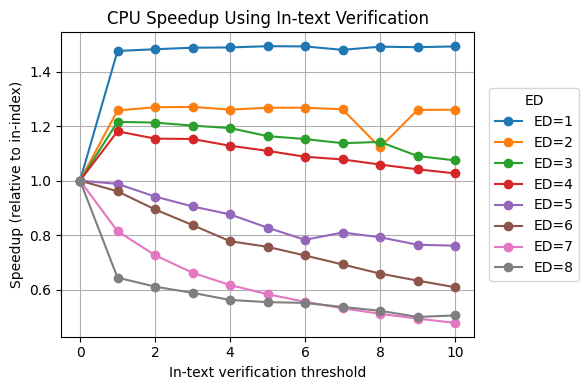

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

for ed, sub in df_cpu.groupby("ED"):
    sub_sorted = sub.sort_values(" intextSwitchpoint")
    ax.errorbar(
        sub_sorted[" intextSwitchpoint"],
        sub_sorted["speedup"],
        #yerr=sub_sorted["speedup_err"],
        marker="o",
        label=f"ED={ed}",
    )

ax.set_xlabel("In-text verification threshold")
ax.set_ylabel("Speedup (relative to in-index)")
ax.set_title("CPU Speedup Using In-text Verification")
ax.grid(True)
ax.legend(
    title="ED",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.tight_layout()
plt.show()
fig.savefig("cpu.pdf")

In [25]:
df_gpu = df.copy()
df_gpu = df_gpu.drop(columns=["CPU_time", "CPU_err","n", "CPU_matches"])
ref = df_gpu[df_gpu[" intextSwitchpoint"] == 0].set_index("ED")["GPU_time"]
ref_err = df_gpu[df_gpu[" intextSwitchpoint"] == 0].set_index("ED")["GPU_err"]
df_gpu["speedup"] = df_gpu["ED"].map(ref)/df_gpu["GPU_time"]
df_gpu["speedup_err"] = df_gpu["speedup"]*((df_gpu["ED"].map(ref_err)/df_gpu["ED"].map(ref))**2+(df_gpu["GPU_err"]/df_gpu["GPU_time"])**2)**(0.5)
df_gpu


,ED,intextSwitchpoint,GPU_time,GPU_err,GPU_matches,speedup,speedup_err
0,1,0,9.458000,1.333009,6385689.0,1.000000,0.199319
1,1,1,8.288000,0.021307,6385689.0,1.141168,0.160863
2,1,2,8.208000,0.018547,6385689.0,1.152290,0.162425
3,1,3,8.164000,0.009274,6385689.0,1.158501,0.163284
4,1,4,8.138000,0.009695,6385689.0,1.162202,0.163806
...,...,...,...,...,...,...,...
83,8,6,2238.160000,NaN,254990237.0,0.700538,NaN
84,8,7,2264.416667,12.830050,254990232.0,0.692415,0.005204
85,8,8,2311.640000,10.085242,254990239.0,0.678270,0.004469
86,8,9,2321.190000,12.077323,254990266.0,0.675479,0.004845


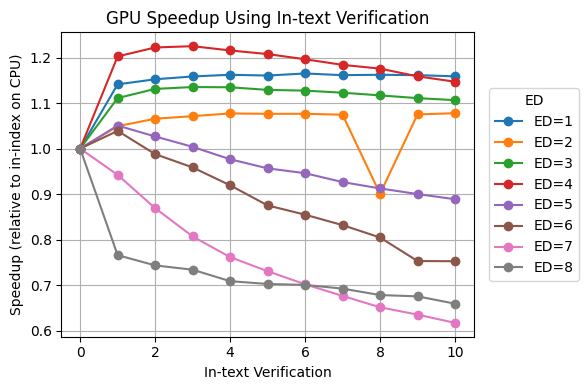

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

for ed, sub in df_gpu.groupby("ED"):
    sub_sorted = sub.sort_values(" intextSwitchpoint")
    ax.errorbar(
        sub_sorted[" intextSwitchpoint"],
        sub_sorted["speedup"],
        #yerr=sub_sorted["speedup_err"],
        marker="o",
        label=f"ED={ed}",
    )

ax.set_xlabel("In-text Verification")
ax.set_ylabel("Speedup (relative to in-index on CPU)")
ax.set_title("GPU Speedup Using In-text Verification")
ax.grid(True)
ax.legend(
    title="ED",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.tight_layout()
plt.show()
fig.savefig("gpu.pdf")

In [27]:
df_gpu_cpu = df.copy()
df_gpu_cpu["speedup"] = df_gpu_cpu["CPU_time"]/df_gpu_cpu["GPU_time"]
df_gpu_cpu["speedup_err"] = df_gpu_cpu["speedup"]*((df_gpu_cpu["GPU_err"]/df_gpu_cpu["GPU_time"])**2+(df_gpu_cpu["CPU_err"]/df_gpu_cpu["CPU_time"])**2)**(0.5)
df_gpu_cpu

,ED,intextSwitchpoint,GPU_time,GPU_err,CPU_time,CPU_err,GPU_matches,CPU_matches,n,speedup,speedup_err
0,1,0,9.458000,1.333009,9.458000,1.333009,6385689.0,6385689.0,5,1.000000,0.199319
1,1,1,8.288000,0.021307,6.408000,0.005831,6385689.0,6385689.0,5,0.773166,0.002109
2,1,2,8.208000,0.018547,6.380000,0.007071,6385689.0,6385689.0,5,0.777290,0.001956
3,1,3,8.164000,0.009274,6.356000,0.006782,6385689.0,6385689.0,5,0.778540,0.001213
4,1,4,8.138000,0.009695,6.352000,0.004899,6385689.0,6385689.0,5,0.780536,0.001108
...,...,...,...,...,...,...,...,...,...,...,...
83,8,6,2238.160000,NaN,2845.310000,NaN,254990237.0,254990385.0,1,1.271272,NaN
84,8,7,2264.416667,12.830050,2923.906667,23.840910,254990232.0,254990382.0,3,1.291241,0.012821
85,8,8,2311.640000,10.085242,3001.753333,33.219204,254990239.0,254990395.0,3,1.298538,0.015447
86,8,9,2321.190000,12.077323,3138.463333,55.946145,254990266.0,254990423.0,3,1.352092,0.025108


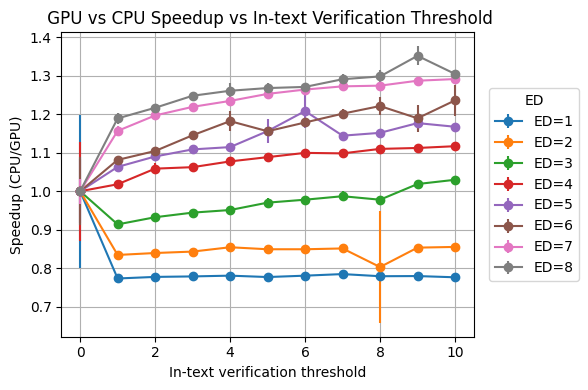

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

for ed, sub in df_gpu_cpu.groupby("ED"):
    sub_sorted = sub.sort_values(" intextSwitchpoint")
    ax.errorbar(
        sub_sorted[" intextSwitchpoint"],
        sub_sorted["speedup"],
        yerr=sub_sorted["speedup_err"],
        marker="o",
        label=f"ED={ed}",
    )

ax.set_xlabel("In-text verification threshold")
ax.set_ylabel("Speedup (CPU/GPU)")
ax.set_title(" GPU vs CPU Speedup vs In-text Verification Threshold")
ax.grid(True)
ax.legend(
    title="ED",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.tight_layout()
plt.show()
fig.savefig("gpu_cpu.pdf")

In [29]:
# alleen rijen met intextSwitchpoint > 0
df_pos = df[df[" intextSwitchpoint"] > 0]

# beste (laagste) GPU-tijd per ED
best_gpu = df_pos.loc[
    df_pos.groupby("ED")["GPU_time"].idxmin()
]

# beste (laagste) CPU-tijd per ED
best_cpu = df_pos.loc[
    df_pos.groupby("ED")["CPU_time"].idxmin()
]

In [30]:
best_gpu_s = best_gpu[["ED", "GPU_time", "GPU_err", "GPU_matches", " intextSwitchpoint"]].copy()
best_cpu_s = best_cpu[["ED", "CPU_time", "CPU_err", "CPU_matches", " intextSwitchpoint"]].copy()
best_gpu_s = best_gpu_s.rename(columns={" intextSwitchpoint": "intextGPU"})
best_cpu_s = best_cpu_s.rename(columns={" intextSwitchpoint": "intextCPU"})
best_all = pd.merge(best_gpu_s, best_cpu_s, on="ED", how="inner")
best_all["speedup"] = best_all["CPU_time"]/best_all["GPU_time"]
best_all["speedup_err"] = best_all["speedup"]*((best_all["GPU_err"]/best_all["GPU_time"])**2+(best_all["CPU_err"]/best_all["CPU_time"])**2)**(0.5)
best_all

,ED,GPU_time,GPU_err,GPU_matches,intextGPU,CPU_time,CPU_err,CPU_matches,intextCPU,speedup,speedup_err
0,1,8.118000,0.012410,6385689.0,6,6.332000,0.002000,6385689.0,5,0.779995,0.001218
1,2,10.872000,0.010198,12870241.0,10,9.222000,0.016553,12870241.0,3,0.848234,0.001718
2,3,18.056000,0.022045,23632628.0,3,16.860000,0.014832,23632628.0,1,0.933762,0.001405
3,4,34.946000,0.040075,41147035.0,3,36.248000,0.046626,41147035.0,1,1.037257,0.001787
4,5,83.156000,0.320852,68767565.0,1,88.420000,0.040373,68767566.0,1,1.063303,0.004131
5,6,149.244000,1.005662,110800608.0,1,161.410000,1.183347,110800614.0,1,1.081518,0.010769
6,7,324.354000,0.884718,171397067.0,1,375.244000,4.304646,171397117.0,1,1.156896,0.013641
7,8,2046.936667,10.677394,254989955.0,1,2434.536667,28.131659,254990056.0,1,1.189356,0.015079


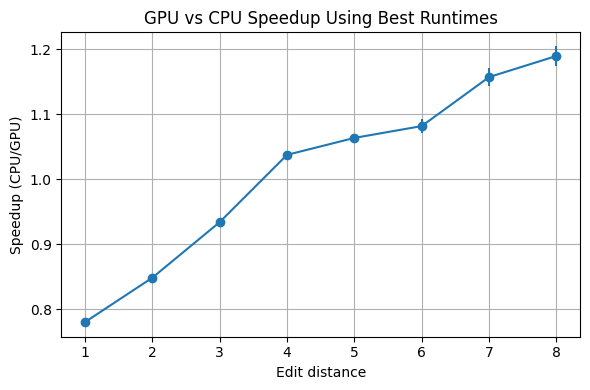

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(best_all["ED"], best_all["speedup"],yerr=best_all['speedup_err'], marker="o")
ax.set_xlabel("Edit distance")
ax.set_ylabel("Speedup (CPU/GPU)")
ax.set_title("GPU vs CPU Speedup Using Best Runtimes")
ax.grid(True)
plt.tight_layout()
plt.show()
fig.savefig("best.pdf")

In [ ]:
extra = pd.read_csv("PhaseTimes.csv")
extra["GPU_time"] = pd.to_timedelta(extra["GPU_time"].apply(mmss_to_seconds),unit="s").dt.total_seconds()
extra["CPU_time"] = pd.to_timedelta(extra["CPU_time"].apply(mmss_to_seconds),unit="s").dt.total_seconds()
extra

,ED,intextSwitchpoint,GPU_time,CPU_time,Threads,GPU_matches,CPU_matches
0,5,1,84.52,80.82,10,68767565,68767636
1,5,2,86.21,80.70,10,68767516,68767636
2,5,1,84.83,81.31,10,68767565,68767636
3,5,2,86.22,80.89,10,68767516,68767636
4,5,1,84.43,85.99,10,68767565,68767636
5,5,2,91.18,87.73,10,68767516,68767636
6,5,1,84.56,83.91,10,68767565,68767636
7,5,2,86.24,80.65,10,68767516,68767636
8,5,1,84.75,87.57,10,68767565,68767636
9,5,2,86.31,80.73,10,68767516,68767636


In [33]:
extra = extra.groupby(["ED", " intextSwitchpoint"]).agg(GPU_mean = ("GPU_time", "mean"),
                                                        GPU_err = ("GPU_time", "std"),
                                                        CPU_mean = ("CPU_time", "mean"),
                                                        CPU_err = ("CPU_time", "std"),
                                                        n = ("GPU_time", "size"),
                                                        GPU_meadian = ("GPU_time", "median"),
                                                        CPU_median = ("CPU_time", "median"))
extra

GPU_mean    GPU_err  CPU_mean    CPU_err   n  \
ED  intextSwitchpoint                                                 
5  1                     85.297   1.833915    87.046   7.214432  10   
   2                     86.637   1.606840    83.336   4.568224  10   
6  1                    151.258   1.649888   144.844  11.721373  10   
   2                    171.878  36.714136   138.177   4.252145  10   

                       GPU_meadian  CPU_median  
ED  intextSwitchpoint                           
5  1                        84.735      85.725  
   2                        86.215      80.845  
6  1                       150.470     140.800  
   2                       157.990     136.130